# Discrete event simulation: Cost-effectiveness of MIPAC Units compared to hospitals in Norway

This notebook implements a discrete event simulation to estimate the cost-effectiveness of treating acute care patients in Municipal Inpatient Acute Care Units (MIPACs) in Norway comapred to hospitals from a healthcare persepctive in Norway

The model used parameters based on data from Norwegian Health Directorate, Statistics Norway and National Patient Registry. The model has four different archetypes based on the data available and simulates admissions, length of stay, capacity constraints, costs and effects.


## The purpose of the model is to:
- Simulate arrival of patients to MIPAC units over one year period
- Model varying referral proportions of GPs to MIPAC units
- Account for limited capacity in MIPAC assuming no waiting
- Route the overflow of patients to hospitals
- Estimate the length of stay of patients, costs and effects

## Simulation overview

    - Time horizon: 730 days
    - Warm up period: 365 days
    - Distribution used for arrival process: Exponential 
    - Distribution used for los: log-normal 
    - Unit of analysis: Individual patients
    - Output: Patient-level cost and functional improvement; others- LOS and pathway 
    - A fixed random seed set for ensuring reproducibility

## Care pathways

Patients follow one of three pathways:
1. MIPAC admission
   -Patient who is suitable for MIPAC
3. Hospital admission when the MIPAC beds are fully occupied
4. Direct hopsital admission for othe reasons than full occupancy


## Key assumptions

1.	All the patients in the model are assumed to be appropriate MIPAC patients.
2.	Patients do not wait for MIPAC beds i.e. they are immediately referred to hospital if there is no bed available. This was done to reflect reality where there is no negotiation on if the beds will be available in a few hours or so. 
3.	Hospital capacity is assumed to be unlimited. This is to reflect the absence of alternatives and obligation of hospitals to accept the patients in need of acute care even when they are full.
4.	Referral rate to MIPACs is assumed to be 70%. The difference in referral probabilities between GP office and OOH GP service not taken into account in the main model. 
5.	No seasonal patterns of admissions in MIPAC has been accounted for in the model. 
6.	Variations like intermunicipal collaboration and geography has not been taken into account in the main model for simplicity. 
7. Length of stay follows a lognormal distribution 

In [1]:
import simpy
import pandas as pd
import numpy as np


In [2]:
import matplotlib.pyplot as plt


In [3]:
!pip install scikit-learn
from sklearn.ensemble import RandomForestRegressor


In [4]:
np.random.seed(12345)

In [5]:

# GLOBAL PARAMETERS
# ============================================================


## I tried with different values of sim_duration and warm up but it seems like the model does not really need any warm up 
## since the number of patients and the number of beds in MIPAC is on the lowe side, I have tried sim duration upto 3650 or 10 years

sim_duration = 730  # days
warmup = 0            # days

# HOSPITAL PARAMETERS
# ============================================================

cost_epi_h = 60681

qaly_h = 0.70

mean_los_h = 2.5
sd_los_h = 1.5

sig2_h = np.log(1 + (sd_los_h**2 / mean_los_h**2))

sig_los_h = np.sqrt(sig2_h)

mu_los_h = (    np.log(mean_los_h)    - 0.5 * sig2_h)

# ============================================================
# NORWEGIAN WTP
# ============================================================

wtp = 275000
WTP_upper = 825000

In [41]:
# MIPAC parameters

# ARCHETYPES
# ============================================================

Archetypes = pd.DataFrame({

    'archetypes':[1,2,3,4],

    'mean_adm_m':[28,110,96,420],

    'mean_los_m':[3.2,2.6,7.2,3.6],

    'sd_los_m':[0.89,0.83,7.68,1.45],

    'mu_los_m':[1.13,0.91,1.60,1.21],

    'sig_los_m':[0.27,0.31,0.87,0.39],

    'mean_beds_m':[1.2,2.2,2.8,9.8],

    'mean_cost_y':[
        1144789.25,
        2646801.11,
        2705353.50,
        8235351.13
    ],

    'qaly_m':[0.80,0.80,0.80,0.80],

    'ref_prob_m':[0.70,0.70,0.70,0.70]

})

Archetypes['mean_costppat_m'] = (    Archetypes['mean_cost_y']    /    Archetypes['mean_adm_m'])


# CHOOSE ARCHETYPE
# ============================================================

k = 4 ##Choose between 1,2,3 and 4



# PARAMETER EXTRACTION
# ============================================================

def archetype_params(archetype):

    row = Archetypes.loc[Archetypes['archetypes'] == archetype].iloc[0]

    return {

        'mean_adm_m': row['mean_adm_m'],
        'mu_los_m': row['mu_los_m'],
        'sig_los_m': row['sig_los_m'],
        'mipac_capacity': max(1, round(row['mean_beds_m'])),
        'mean_costppat_m': row['mean_costppat_m'],
        'qaly_m': row['qaly_m'],
        'ref_prob_m': row['ref_prob_m'],
        'mu_los_h': mu_los_h,
        'sig_los_h': sig_los_h,
        'cost_epi_h': cost_epi_h,
        'qaly_h': qaly_h
    }

params = archetype_params(k)

In [42]:
# PATIENT ARRIVALS
# ============================================================

def patient_gen(params, sim_duration, seed=None):

    arrivals = []
    t = 0
    pid = 0

    while t < sim_duration:

        interarrival = np.random.exponential(scale=365 / params['mean_adm_m'])
        t += interarrival
        if t >= sim_duration:
            break
        arrivals.append((pid,t))

        pid += 1

    return arrivals

# ============================================================
# STRATEGY ARM
# ============================================================

def patient_process_MIPAC(env, pid, arrival_time, MIPAC, params, stats):

    # Patient arrives
    yield env.timeout(arrival_time)

    # Default values (for patients who never enter MIPAC)
    t_in = None
    t_out = None

    # Referral decision
    if np.random.random() < params['ref_prob_m']:

        with MIPAC.request() as req:

            result = yield req | env.timeout(0)

            if req in result:   # Patient admitted to MIPAC
                t_in = env.now

                los = np.random.lognormal(params['mu_los_m'], params['sig_los_m'])
                yield env.timeout(los)

                t_out = env.now

                pathway = "MIPAC"
                cost = params['mean_costppat_m']
                qaly = params['qaly_m']

            else:               # No bed available → hospital
                los = np.random.lognormal(params['mu_los_h'], params['sig_los_h'])
                yield env.timeout(los)

                pathway = "Hospital_NoBed"
                cost = params['cost_epi_h']
                qaly = params['qaly_h']

    else:   # Not referred → direct hospital
        los = np.random.lognormal(params['mu_los_h'], params['sig_los_h'])
        yield env.timeout(los)

        pathway = "Direct_Hospital"
        cost = params['cost_epi_h']
        qaly = params['qaly_h']

    # Store only after warmup
    if arrival_time > warmup:
        stats.append({
            'id': pid,
            'pathway': pathway,
            'cost': cost,
            'LOS': los,
            'qaly': qaly,
            't_MIPAC_in': t_in,
            't_MIPAC_out': t_out
        })

        
# ============================================================
# COMPARATOR ARM
# ============================================================

def patient_process_NoMIPAC(env,pid,arrival_time,params,stats):

    yield env.timeout(arrival_time)

    los = np.random.lognormal(params['mu_los_h'],params['sig_los_h'])

    yield env.timeout(los)

    if arrival_time > warmup:

        stats.append({

            'id': pid,

            'pathway': 'Hospital_Only',

            'cost': params['cost_epi_h'],

            'LOS': los,

            'qaly': params['qaly_h']
        })

In [8]:
# RUN STRATEGY
# ============================================================

def run_strategy(arrivals,params):

    env = simpy.Environment()

    stats = []

    MIPAC = simpy.Resource(env,capacity=params['mipac_capacity'])

    for pid,arrival in arrivals:

        env.process(patient_process_MIPAC(env,pid,arrival,MIPAC,params,stats))

    env.run()

    return pd.DataFrame(stats)


# RUN COMPARATOR
# ============================================================

def run_comparator(arrivals,params):

    env = simpy.Environment()

    stats = []

    for pid,arrival in arrivals:

        env.process(patient_process_NoMIPAC(env,pid,arrival,params,stats))

    env.run()

    return pd.DataFrame(stats)


## Run this only if you want to see if there are patients in each branch of the arm 

arrivals=patient_gen(params,sim_duration=sim_duration)
df_strategy=run_strategy(arrivals,params)
print(df_strategy)


arrivals=patient_gen(params,sim_duration=sim_duration)
df_comparator=run_comparator(arrivals,params)
print(df_comparator)

In [9]:
# AGGREGATE
# ============================================================

def aggregate(df):

    return {

        'n':
            len(df),

        'mean_cost':
            df['cost'].mean(),

        'mean_qaly':
            df['qaly'].mean()
    }


# ICER
# ============================================================

def calc_icer(strategy,comparator):

    dc = (strategy['mean_cost']  -  comparator['mean_cost'])

    dq = (strategy['mean_qaly']  -  comparator['mean_qaly'])

    return {
        'Incremental Cost': dc,

        'Incremental QALY': dq,

        'ICER': dc/dq
    }

In [10]:

# BASE CASE
# ============================================================

arrivals = patient_gen(params, sim_duration)

df_strategy = run_strategy(arrivals,params)

df_comparator = run_comparator(arrivals,params)

agg_strategy = aggregate(df_strategy)

agg_comparator = aggregate(df_comparator)

results = calc_icer(agg_strategy,agg_comparator)

In [11]:
def run_cea_once(params, sim_duration):

    arrivals = patient_gen(params, sim_duration)

    df_s = run_strategy(arrivals, params)
    df_c = run_comparator(arrivals, params)

    agg_s = aggregate(df_s)
    agg_c = aggregate(df_c)

    icer = calc_icer(agg_s, agg_c)

    return agg_s, agg_c, icer


In [12]:
print(results)

{'Incremental Cost': -28691.140046890072, 'Incremental QALY': 0.06985398021667444, 'ICER': -410730.21119047666}


In [13]:

# ============================================================
# OUTPUTS
# ============================================================

print("\nBASE CASE RESULTS")
print(results)

print("\nStrategy Pathways")
print(
    df_strategy['pathway']
    .value_counts()
)

print("\nComparator Pathways")
print(
    df_comparator['pathway']
    .value_counts()
)


BASE CASE RESULTS
{'Incremental Cost': -28691.140046890072, 'Incremental QALY': 0.06985398021667444, 'ICER': -410730.21119047666}

Strategy Pathways
pathway
MIPAC              1483
Direct_Hospital     638
Hospital_NoBed        2
Name: count, dtype: int64

Comparator Pathways
pathway
Hospital_Only    2123
Name: count, dtype: int64


In [14]:
##to check if the number of patients is identical in both strategy and comparator arms


set_s = set(df_strategy.id)
set_c = set(df_comparator.id)

print(len(set_s))
print(len(set_c))

print(set_s.symmetric_difference(set_c))

2123
2123
set()


In [15]:
for rep in range(200):
    agg_s, agg_c, icer = run_cea_once(params, sim_duration)
    print(icer)


{'Incremental Cost': -27993.684545966862, 'Incremental QALY': 0.06815589353612161, 'ICER': -410730.2111904765}
{'Incremental Cost': -28995.035023695495, 'Incremental QALY': 0.07059386973180093, 'ICER': -410730.21119047527}
{'Incremental Cost': -28701.147604356385, 'Incremental QALY': 0.0698783454987838, 'ICER': -410730.2111904741}
{'Incremental Cost': -28603.370103048986, 'Incremental QALY': 0.06964028776978426, 'ICER': -410730.2111904756}
{'Incremental Cost': -28528.939034819574, 'Incremental QALY': 0.06945907132599338, 'ICER': -410730.2111904757}
{'Incremental Cost': -28647.083679185645, 'Incremental QALY': 0.0697467166979362, 'ICER': -410730.2111904762}
{'Incremental Cost': -28895.49728125413, 'Incremental QALY': 0.07035152636447728, 'ICER': -410730.21119047655}
{'Incremental Cost': -28749.11414908496, 'Incremental QALY': 0.06999512907939609, 'ICER': -410730.2111904756}
{'Incremental Cost': -28939.13191634643, 'Incremental QALY': 0.07045776309579976, 'ICER': -410730.21119047696}
{'I

In [16]:
def cluster_occupancy(df, capacity, sim_duration, warmup=0):
    """
    Compute occupancy rate for MIPAC (overall or per cluster if cluster column exists).
    """

    # Only patients who actually entered MIPAC
    df_use = df[df['t_MIPAC_in'].notna()].copy()

    # Only after warmup
    df_use = df_use[df_use['t_MIPAC_in'] >= warmup]

    # Time spent in MIPAC
    df_use['mipac_time'] = df_use['t_MIPAC_out'] - df_use['t_MIPAC_in']

    T = sim_duration - warmup

    # If cluster column exists → group by cluster
    if 'cluster' in df_use.columns:
        occ = df_use.groupby('cluster')['mipac_time'].sum() / (capacity * T)
    else:
        occ = df_use['mipac_time'].sum() / (capacity * T)

    return occ

df_strategy = run_strategy(arrivals, params)

occ = cluster_occupancy(
    df_strategy,
    capacity=params['mipac_capacity'],
    sim_duration=sim_duration,
    warmup=365
)

print("MIPAC occupancy:")
print(occ)


MIPAC occupancy:
0.2959829497844982


In [17]:
## To check if the model is correct in ccalculating the MIPAC occupancy


lam = params['mean_adm_m'] / 365          # arrivals per day
p    = params['ref_prob_m']
E_los = np.exp(params['mu_los_m'] + 0.5 * params['sig_los_m']**2)  # mean of lognormal
cap  = params['mipac_capacity']

rho_theory = lam * p * E_los / cap
print(rho_theory)

0.2914599488892089


In [18]:

def blockage_for_admissions(archetype, admissions, sim_duration=730, seed=123):
    """Run DES for a given archetype and admission level."""
    p = archetype_params(archetype).copy()
    p['mean_adm_m'] = admissions
    arrivals = patient_gen(p, sim_duration, seed)
    df = run_strategy(arrivals, p)
    if df.empty:
        return 0
    return (df['pathway'] == 'Hospital_NoBed').sum()


# ============================================================
# SEARCH FOR THRESHOLD (first admissions level with blockage)
# ============================================================

def find_threshold(archetype, max_multiplier=3.0, steps=30):
    base = archetype_params(archetype)
    base_adm = base['mean_adm_m']

    # test admissions from base to 3×base
    test_values = np.linspace(base_adm, base_adm * max_multiplier, steps)

    for adm in test_values:
        blocked = blockage_for_admissions(archetype, adm)
        if blocked > 0:
            return {
                'archetype': archetype,
                'base_admissions': base_adm,
                'threshold_admissions': adm,
                'extra_needed': adm - base_adm,
                'blocked_at_threshold': blocked
            }

    # if no blockage even at 3× load
    return {
        'archetype': archetype,
        'base_admissions': base_adm,
        'threshold_admissions': None,
        'extra_needed': None,
        'blocked_at_threshold': 0
    }


# Run for all archetypes
thresholds = [find_threshold(a) for a in [1, 2, 3, 4]]
df_thresholds = pd.DataFrame(thresholds)
print(df_thresholds)


   archetype  base_admissions  threshold_admissions  extra_needed  \
0          1             28.0             28.000000      0.000000   
1          2            110.0            110.000000      0.000000   
2          3             96.0             96.000000      0.000000   
3          4            420.0            477.931034     57.931034   

   blocked_at_threshold  
0                     2  
1                    23  
2                    13  
3                     1  


     capacity  multiplier  occupancy   blocked
0           3    1.000000   0.527503  0.289305
1           3    1.208333   0.530264  0.365904
2           3    1.416667   0.463333  0.448884
3           3    1.625000   0.453018  0.489265
4           3    1.833333   0.413520  0.542277
..        ...         ...        ...       ...
120         7    5.166667   0.181032  0.636153
121         7    5.375000   0.140451  0.661161
122         7    5.583333   0.121302  0.669548
123         7    5.791667   0.093421  0.677565
124         7    6.000000   0.078900  0.673908

[125 rows x 4 columns]


In [20]:
# One way sensitivity analysis
###############################

def run_cea_once(params, sim_duration):
    arrivals = patient_gen(params, sim_duration=sim_duration)

    df_strategy   = run_strategy(arrivals, params)
    df_comparator = run_comparator(arrivals, params)

    agg_strategy   = aggregate(df_strategy)
    agg_comparator = aggregate(df_comparator)

    icer_results = calc_icer(agg_strategy, agg_comparator)

    return agg_strategy, agg_comparator, icer_results



## Referral probability as the variable 

ref_values = np.linspace(0.5, 1.0, 6)  # 0.5, 0.6, ..., 1.0

owsa_ref = []

for p in ref_values:
    params_ref = params.copy()
    params_ref['ref_prob_m'] = p

    _, _, icer = run_cea_once(params_ref, sim_duration)

    owsa_ref.append({
        'ref_prob_m': p,
        'Incremental Cost': icer['Incremental Cost'],
        'Incremental QALY': icer['Incremental QALY'],
        'ICER': icer['ICER']
    })

owsa_ref_df = pd.DataFrame(owsa_ref)
print("\nOWSA – Referral probability")
print(owsa_ref_df)






OWSA – Referral probability
   ref_prob_m  Incremental Cost  Incremental QALY           ICER
0         0.5      -3402.402463          0.008284 -410730.211190
1         0.6      -2216.524565          0.005397 -410730.211190
2         0.7       -907.352117          0.002209 -410730.211190
3         0.8       -496.330715          0.001208 -410730.211190
4         0.9       -155.248840          0.000378 -410730.211191
5         1.0        -65.350869          0.000159 -410730.211190


In [21]:
cost_multipliers = [1.5,2,2.5,3,3.5, 4,4.5, 5]

owsa_cost = []

for m in cost_multipliers:
    params_cost = params.copy()
    params_cost['mean_costppat_m'] = params['mean_costppat_m'] * m

    _, _, icer = run_cea_once(params_cost, sim_duration)

    owsa_cost.append({
        'cost_multiplier': m,
        'Incremental Cost': icer['Incremental Cost'],
        'Incremental QALY': icer['Incremental QALY'],
        'ICER': icer['ICER']
    })

owsa_cost_df = pd.DataFrame(owsa_cost)
print("\nOWSA – MIPAC cost multiplier")
print(owsa_cost_df)



OWSA – MIPAC cost multiplier
   cost_multiplier  Incremental Cost  Incremental QALY           ICER
0              1.5       -759.471789          0.002429 -312690.316786
1              2.0       -536.201846          0.002498 -214650.422381
2              2.5       -298.001588          0.002556 -116610.527976
3              3.0        -41.954180          0.002259  -18570.633571
4              3.5        194.549212          0.002448   79469.260833
5              4.0        461.935346          0.002602  177509.155238
6              4.5        597.091448          0.002167  275549.049643
7              5.0       1122.128783          0.003004  373588.944048


In [22]:
## Two way sensitivity analysis using cost of MIPAC and QALy from MIPAC

cost_multipliers = np.array([2, 2.5, 3, 3.5, 4, 4.5, 5])
qaly_values = [0.6]   # QALY must be between 0 and 1

results = []

for cm in cost_multipliers:
    for qv in qaly_values:
        params_2w = params.copy()
        params_2w['mean_costppat_m'] = params['mean_costppat_m'] * cm
        params_2w['qaly_m']          = qv   # DIRECTLY set QALY to 0.6 

        _, _, icer = run_cea_once(params_2w, sim_duration)

        results.append({
            'cost_multiplier': cm,
            'qaly_m_value': qv,
            'Incremental Cost': icer['Incremental Cost'],
            'Incremental QALY': icer['Incremental QALY'],
            'ICER': icer['ICER']
        })

owsa_2w_df = pd.DataFrame(results)
print(owsa_2w_df)


   cost_multiplier  qaly_m_value  Incremental Cost  Incremental QALY  \
0              2.0           0.6       -498.951025         -0.002324   
1              2.5           0.6       -287.012812         -0.002461   
2              3.0           0.6        -51.861656         -0.002793   
3              3.5           0.6        180.484655         -0.002271   
4              4.0           0.6        384.400486         -0.002166   
5              4.5           0.6        597.070327         -0.002167   
6              5.0           0.6        965.820744         -0.002585   

            ICER  
0  214650.422381  
1  116610.527976  
2   18570.633571  
3  -79469.260833  
4 -177509.155238  
5 -275549.049643  
6 -373588.944048  


In [38]:
print(type(params))
print(params)


<class 'list'>
['ref_prob_m', 'mean_costppat_m', 'qaly_m', 'cost_epi_h', 'qaly_h']


In [23]:
### to find out how occupancy and blockage works in a MIPAC unit

capacities = [1, 2, 3, 4, 5]
results = []

for cap in capacities:
    params_run = params.copy()          # make a fresh dict
    params_run['mipac_capacity'] = cap  # modify capacity

    df = run_strategy(arrivals, params_run)  # <-- use params_run

    occ = cluster_occupancy(df, capacity=cap, sim_duration=sim_duration, warmup=365)
    blocked = (df['pathway'] == 'Hospital_NoBed').mean()

    results.append({
        'capacity': cap,
        'occupancy': occ,
        'blocked': blocked
    })

df_res = pd.DataFrame(results)
print(df_res)


   capacity  occupancy   blocked
0         1   0.313772  0.624588
1         2   0.453768  0.490344
2         3   0.524999  0.337259
3         4   0.523513  0.219972
4         5   0.503061  0.112577


In [24]:
def run_des_timeseries(arrivals, params, sim_duration):
    df = run_strategy(arrivals, params)

    # Only MIPAC patients have valid in/out times
    mipac_df = df[df['pathway'] == 'MIPAC']

    occ_ts = np.zeros(sim_duration)

    for day in range(sim_duration):
        occ_ts[day] = ((mipac_df['t_MIPAC_in'] <= day) &
                       (mipac_df['t_MIPAC_out'] > day)).sum()

    return occ_ts


    
n_rep = 200
all_ts = []

for r in range(n_rep):
    ts = run_des_timeseries(arrivals, params, sim_duration)
    all_ts.append(ts)

all_ts = np.array(all_ts)


avg_ts = all_ts.mean(axis=0)


def welch_smooth(series, window=20):
    smoothed = np.zeros_like(series)
    T = len(series)
    for t in range(T):
        start = max(0, t - window)
        end = min(T, t + window)
        smoothed[t] = series[start:end].mean()
    return smoothed

smooth_ts = welch_smooth(avg_ts, window=20)




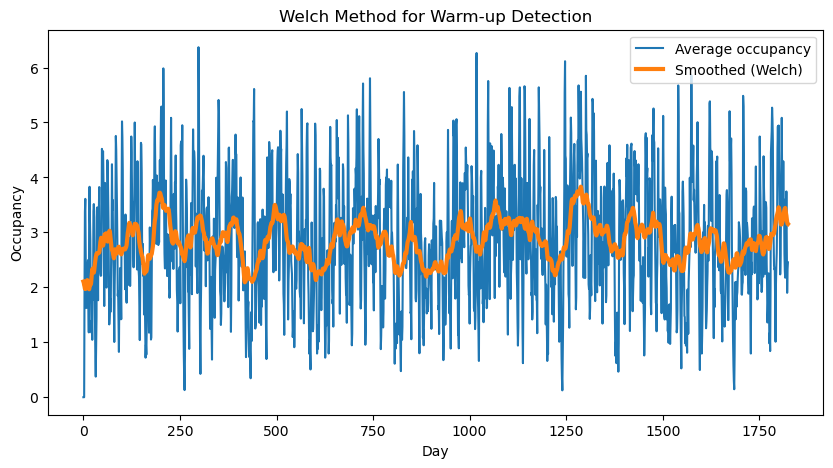

In [25]:
plt.figure(figsize=(10,5))
plt.plot(avg_ts, label="Average occupancy")
plt.plot(smooth_ts, label="Smoothed (Welch)", linewidth=3)
plt.xlabel("Day")
plt.ylabel("Occupancy")
plt.title("Welch Method for Warm-up Detection")
plt.legend()
plt.show()


## Probabilistic Sensitivity Analysis

Uncertainty in input parameters: Cost of both hospitals and MIPAC, QALY, referral probability

The distribution used for input parameters in PSA:

Cost--> Gamma distribution (mean and standard deviation)
Referral probability-->Beta distribution (alpha and beta)
QALY-->Beta distribution (mean utility and SD)

In [40]:
print(type(params))
print(params)


<class 'list'>
['ref_prob_m', 'mean_costppat_m', 'qaly_m', 'cost_epi_h', 'qaly_h']


In [44]:
# ============================================================
# PROPER PSA (Beta for probabilities/QALYs, Gamma for costs)
# ============================================================

n_psa = 1000
rng = np.random.default_rng()

psa_records = []

for i in range(n_psa):

 
    p = params.copy()

    # 0. Arrival rate (Poisson around observed mean)
    base_mean = p['mean_adm_m']          
    p['mean_adm_m'] = max(1, rng.poisson(lam=base_mean))

    # 1. Referral probability (Beta)
    mean = p['ref_prob_m']
    sd   = 0.10 * mean
    alpha = mean * ((mean*(1-mean)/sd**2) - 1)
    beta  = (1-mean) * ((mean*(1-mean)/sd**2) - 1)
    p['ref_prob_m'] = rng.beta(alpha, beta)

   
    # -----------------------------
    # 1. Referral probability (Beta)
    # -----------------------------
    mean = p['ref_prob_m']
    sd   = 0.20 * mean
    alpha = mean * ((mean*(1-mean)/sd**2) - 1)
    beta  = (1-mean) * ((mean*(1-mean)/sd**2) - 1)
    p['ref_prob_m'] = rng.beta(alpha, beta)

    # -----------------------------
    # 2. MIPAC cost (Gamma)
    # -----------------------------
    mean = p['mean_costppat_m']
    sd   = 0.20 * mean
    k     = (mean/sd)**2
    theta = sd**2 / mean
    p['mean_costppat_m'] = rng.gamma(k, theta)

    # -----------------------------
    # 3. MIPAC QALY (Beta)
    # -----------------------------
    mean = p['qaly_m']
    sd   = 0.20 * mean
    alpha = mean * ((mean*(1-mean)/sd**2) - 1)
    beta  = (1-mean) * ((mean*(1-mean)/sd**2) - 1)
    p['qaly_m'] = rng.beta(alpha, beta)

    # -----------------------------
    # 4. Hospital cost (Gamma)
    # -----------------------------
    mean = p['cost_epi_h']
    sd   = 0.20 * mean
    k     = (mean/sd)**2
    theta = sd**2 / mean
    p['cost_epi_h'] = rng.gamma(k, theta)

    # -----------------------------
    # 5. Hospital QALY (Beta)
    # -----------------------------
    mean = p['qaly_h']
    sd   = 0.20 * mean
    alpha = mean * ((mean*(1-mean)/sd**2) - 1)
    beta  = (1-mean) * ((mean*(1-mean)/sd**2) - 1)
    p['qaly_h'] = rng.beta(alpha, beta)

    # -----------------------------
    # Run DES for this PSA draw
    # -----------------------------

    agg_s, agg_c, icer = run_cea_once(p, sim_duration)

    psa_records.append({
    # store sampled parameters
    'ref_prob_m': p['ref_prob_m'],
    'mean_costppat_m': p['mean_costppat_m'],
    'qaly_m': p['qaly_m'],
    'cost_epi_h': p['cost_epi_h'],
    'qaly_h': p['qaly_h'],

    # store outcomes
    'cost_s': agg_s['mean_cost'],
    'qaly_s': agg_s['mean_qaly'],
    'cost_c': agg_c['mean_cost'],
    'qaly_c': agg_c['mean_qaly'],
    'dC': icer['Incremental Cost'],
    'dQ': icer['Incremental QALY'],
    'ICER': icer['ICER']
})


psa_df = pd.DataFrame(psa_records)
print(psa_df.head())


   ref_prob_m  mean_costppat_m    qaly_m    cost_epi_h    qaly_h  \
0    0.675764     17069.500632  0.778406  81391.789463  0.389514   
1    0.867893     17937.265743  0.940412  71041.062141  0.826765   
2    0.583119     20500.678143  0.816484  43970.066763  0.847750   
3    0.821258     21149.327445  0.594639  79557.654177  0.509098   
4    0.840511     11483.152609  0.864877  62091.378452  0.743929   

         cost_s    qaly_s        cost_c    qaly_c            dC        dQ  \
0  37978.315533  0.651992  81391.789463  0.389514 -43413.473930  0.262478   
1  25399.967703  0.924441  71041.062141  0.826765 -45641.094438  0.097677   
2  29978.478466  0.829111  43970.066763  0.847750 -13991.588297 -0.018640   
3  31255.248610  0.579838  79557.654177  0.509098 -48302.405568  0.070740   
4  19617.047204  0.845438  62091.378452  0.743929 -42474.331247  0.101509   

            ICER  
0 -165398.596911  
1 -467267.493422  
2  750624.156435  
3 -682813.922717  
4 -418429.325266  


In [45]:
dQ = psa_df['dQ']
dC = psa_df['dC']

# Quadrant definitions
quad_I   = (dQ > 0)  & (dC > 0)
quad_II  = (dQ > 0)  & (dC < 0)
quad_III = (dQ < 0) & ( dC < 0)
quad_IV  = (dQ < 0) & (dC > 0)

N = len(psa_df)

# Counts
count_I   = quad_I.sum()
count_II  = quad_II.sum()
count_III = quad_III.sum()
count_IV  = quad_IV.sum()

# Percentages
pct_I   = 100 * count_I   / N
pct_II  = 100 * count_II  / N
pct_III = 100 * count_III / N
pct_IV  = 100 * count_IV  / N

# Print only non‑zero quadrants
print("\nPERCENTAGE OF PSA POINTS IN EACH QUADRANT\n")

if count_I > 0:
    print(f"Quadrant I (More effective, more costly): {pct_I:.1f}%")

if count_II > 0:
    print(f"Quadrant II (More effective, less costly): {pct_II:.1f}%")

if count_III > 0:
    print(f"Quadrant III (Less effective, less costly): {pct_III:.1f}%")

if count_IV > 0:
    print(f"Quadrant IV (Less effective, more costly): {pct_IV:.1f}%")



PERCENTAGE OF PSA POINTS IN EACH QUADRANT

Quadrant II (More effective, less costly): 71.7%
Quadrant III (Less effective, less costly): 28.3%


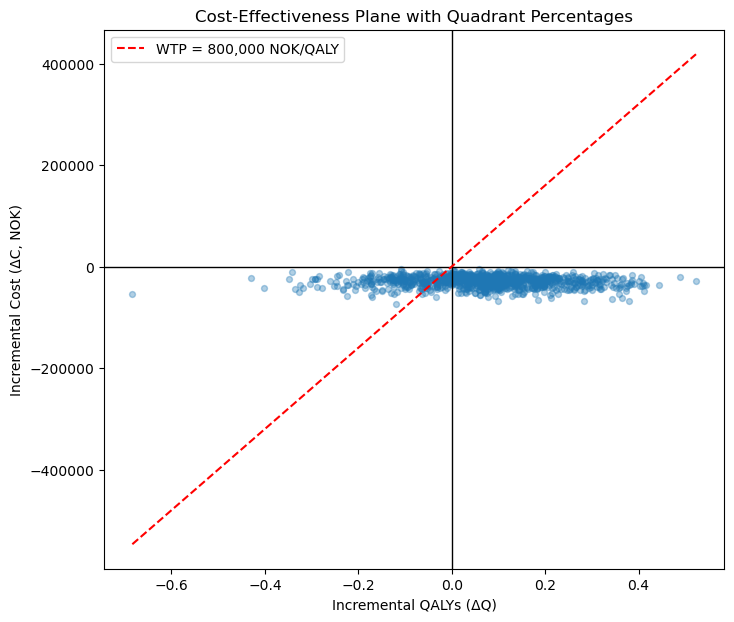

In [46]:
# CE PLOT


plt.figure(figsize=(8,7))

# Axes
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)

# Scatter
plt.scatter(dQ, dC, alpha=0.35, s=18, color='tab:blue')

# WTP line
q_line = np.linspace(dQ.min(), dQ.max(), 200)
plt.plot(q_line, wtp * q_line, '--', color='red', label=f"WTP = {wtp:,} NOK/QALY")

# Axis labels
plt.xlabel("Incremental QALYs (ΔQ)")
plt.ylabel("Incremental Cost (ΔC, NOK)")
plt.title("Cost-Effectiveness Plane with Quadrant Percentages")


plt.legend()
plt.show()


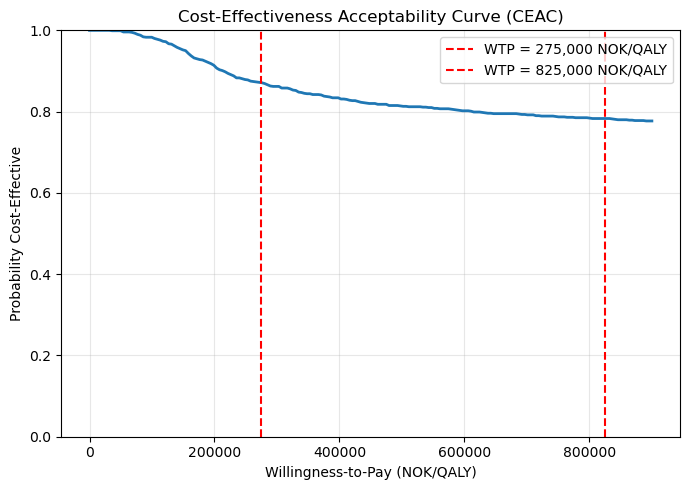

In [47]:
# ============================================
# CEAC
# ============================================

wtp_grid = np.linspace(0, 900000, 200)   # or any range you want

ceac = []

for wtp in wtp_grid:
    # Incremental Net Monetary Benefit
    incr_nmb = wtp * psa_df['dQ'] - psa_df['dC']
    p_ce = np.mean(incr_nmb > 0)
    ceac.append({'WTP': wtp, 'P_CE': p_ce})

ceac_df = pd.DataFrame(ceac)

# Plot CEAC
plt.figure(figsize=(7,5))
plt.plot(ceac_df['WTP'], ceac_df['P_CE'], linewidth=2)
plt.axvline(275000, color='red', linestyle='--', label='WTP = 275,000 NOK/QALY')
plt.axvline(825000, color='red', linestyle='--', label='WTP = 825,000 NOK/QALY')
plt.ylim(0,1)
plt.xlabel("Willingness-to-Pay (NOK/QALY)")
plt.ylabel("Probability Cost-Effective")
plt.title("Cost-Effectiveness Acceptability Curve (CEAC)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


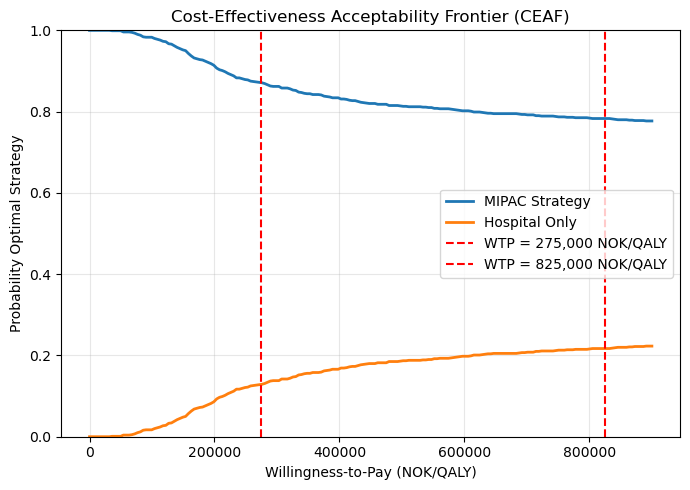

In [48]:
# ============================================
# CEAF
# ============================================

ceaf = []

for wtp in wtp_grid:
    # Net Monetary Benefit for each strategy
    nmb_s = psa_df['qaly_s'] * wtp - psa_df['cost_s']
    nmb_c = psa_df['qaly_c'] * wtp - psa_df['cost_c']

    # Which strategy is optimal in each PSA draw?
    optimal = np.where(nmb_s > nmb_c, 'Strategy', 'Comparator')

    ceaf.append({
        'WTP': wtp,
        'P_opt_strategy': np.mean(optimal == 'Strategy'),
        'P_opt_comparator': np.mean(optimal == 'Comparator')
    })

ceaf_df = pd.DataFrame(ceaf)

# Plot CEAF
plt.figure(figsize=(7,5))
plt.plot(ceaf_df['WTP'], ceaf_df['P_opt_strategy'], label="MIPAC Strategy", linewidth=2)
plt.plot(ceaf_df['WTP'], ceaf_df['P_opt_comparator'], label="Hospital Only", linewidth=2)
plt.axvline(275000, color='red', linestyle='--', label='WTP = 275,000 NOK/QALY')
plt.axvline(825000, color='red', linestyle='--', label='WTP = 825,000 NOK/QALY')
plt.ylim(0,1)
plt.xlabel("Willingness-to-Pay (NOK/QALY)")
plt.ylabel("Probability Optimal Strategy")
plt.title("Cost-Effectiveness Acceptability Frontier (CEAF)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [49]:
psa_df[['dC','dQ']].describe()


,dC,dQ
count,1000.000000,1000.000000
mean,-28995.324388,0.072516
std,11038.955264,0.148658
min,-73368.521744,-0.683818
25%,-35907.167178,-0.015732
50%,-27499.519899,0.074992
75%,-20966.944287,0.170739
max,-5553.681451,0.523003


In [50]:
# Net Monetary Benefit for each strategy

wtp = 275000
psa_df['NMB_s'] = psa_df['qaly_s'] * wtp - psa_df['cost_s']
psa_df['NMB_c'] = psa_df['qaly_c'] * wtp - psa_df['cost_c']

# Incremental NMB
psa_df['INMB'] = psa_df['NMB_s'] - psa_df['NMB_c']

# EVPI per patient
evpi = psa_df[['NMB_s','NMB_c']].max(axis=1).mean() - \
       psa_df[['NMB_s','NMB_c']].mean().max()


print("EVPI per patient:", evpi)


EVPI per patient: 2762.046773891663


In [51]:
# Net Monetary Benefit for each strategy

wtp = 800000
psa_df['NMB_s'] = psa_df['qaly_s'] * wtp - psa_df['cost_s']
psa_df['NMB_c'] = psa_df['qaly_c'] * wtp - psa_df['cost_c']

# Incremental NMB
psa_df['INMB'] = psa_df['NMB_s'] - psa_df['NMB_c']

# EVPI per patient
evpi = psa_df[['NMB_s','NMB_c']].max(axis=1).mean() - \
       psa_df[['NMB_s','NMB_c']].mean().max()


print("EVPI per patient:", evpi)


EVPI per patient: 16878.810469291988


In [52]:
## EVPPI for each parameter 

params = [
    'ref_prob_m',
    'mean_costppat_m',
    'qaly_m',
    'cost_epi_h',
    'qaly_h'
]

evppi_results = {}

for p in params:
    X = psa_df[[p]] 
    y = psa_df['INMB'] # this is the observed Incremental net monetary benefit

    model = RandomForestRegressor() ## this regressor is more powerful than a linear regression because it allows the relationship to be more than linear
    model.fit(X, y)

    # Expected INMB with perfect information on this parameter
    evppi = model.predict(X).mean() - y.mean()
    evppi_results[p] = evppi

# Convert to table
evppi_df = pd.DataFrame.from_dict(evppi_results, orient='index', columns=['EVPPI'])
print(evppi_df)


                       EVPPI
ref_prob_m       -355.406248
mean_costppat_m  1211.063076
qaly_m           -210.080162
cost_epi_h        424.317453
qaly_h            -37.089195
